          +-------------------+         +-------------------+
          |                   |         |                   |
          |  Single-Cell Data  |         |   Raman Data      |
          |      (x_ref)       |         |     (x_raman)     |
          +---------+---------+         +---------+---------+
                    |                             |
        +-----------v-----------+     +-----------v-----------+
        |      Ref VAE (已训练)   |     |       Raman VAE        |
        | Encoder + Decoder      |     | Encoder + Decoder      |
        +-----------+-----------+     +-----------+-----------+
                    |                             |
              +-----v------+              +------v------+
              |   z_ref    |              |   z_raman   |
              +-----+------+              +------+------+
                    |                            |
                    +-------------+--------------+
                                  |
                           +------v------+
                           | Discriminator|  <--- 判别是否来自ref or raman
                           +------+-------+
                                  |
                +-----------------+-----------------+
                |                                   |
     +----------v----------+           +-----------v-----------+
     |  细胞类型分类器 (已训练)  |           |  Raman 数据重建 (Decoder) |
     +---------------------+           +----------------------+


In [1]:
import scanpy as sc
from torch.utils.data import TensorDataset, DataLoader
import torch

In [2]:
# 检查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
# 打印设备信息
print(f"Using device: {device}")

# 创建一个张量并将其移动到指定设备
tensor = torch.randn(3, 3).to(device)
print(tensor)

Using device: cpu
tensor([[ 1.7086, -1.5854,  0.3343],
        [-1.0769,  0.7430,  1.3997],
        [-1.8554, -0.1511, -1.1180]])


In [3]:
###### BELOW are more models and more losses

# we now have information regarding the spatiality of the VIM gene

import os


# no tesnorflow, being very uncooperative
import torch
# import torchvision
# import torchsummary

import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils as U
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


import numpy as np
import scipy as sp
import pandas as pd

import sys
sys.path.extend([".", ".."])

def turn_on_model(model):
    for param in model.parameters():
        param.requires_grad = True
        
def turn_off_model(model):
    for param in model.parameters():
        param.requires_grad = False

        
# better new arch    
class StandardEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512):
        super(StandardEncoder, self).__init__()
        self.part1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  # x tra here
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),  # x tra end 
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
#             nn.Linear(512, 512),
#             nn.BatchNorm1d(512),
#             nn.ReLU(),
        )
        
        self.to_mean = nn.Linear(hidden_dim, latent_dim)
        self.to_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.latent_dim = latent_dim
    
    def forward(self, x):
        x = self.part1(x)
        return self.to_mean(x), self.to_logvar(x)
    
    
class StandardDecoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512, no_final_relu=False):
        super(StandardDecoder, self).__init__()
     
        
        # this is for the case of non-zinb
        if no_final_relu:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),  # x tra start here
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),  # xtra end
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
#                 nn.ReLU(),  # do the activation here
            )
            
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),  # x tra start here
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),  # xtra end
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
                nn.ReLU(),  # do the activation here
            )
        
        self.latent_dim = latent_dim
    
    # returns a tuple regardless
    def forward(self, x):
        res = self.net(x)
        return res


class Discriminator(nn.Module):
    def __init__(self, latent_dim, spectral=True, end_dim=2):
        super(Discriminator, self).__init__()
        if spectral:
            self.net = nn.Sequential(
                U.spectral_norm(nn.Linear(latent_dim, 1<<6)),
                nn.ReLU(),
                U.spectral_norm(nn.Linear(1<<6, 1<<5)),
                nn.ReLU(),
                U.spectral_norm(nn.Linear(1<<5, 1<<5)),
                nn.ReLU(),
                U.spectral_norm(nn.Linear(1<<5, end_dim)),
    #             nn.Sigmoid(), just do w logits for now 
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, 1<<6),
                nn.ReLU(),
                nn.Linear(1<<6, 1<<5),
                nn.ReLU(),
                nn.Linear(1<<5, 1<<5),
                nn.ReLU(),
                nn.Linear(1<<5, end_dim),
    #             nn.Sigmoid(), just do w logits for now 
            )
        
    def forward(self, x):
        return self.net(x)
    
class VAE(nn.Module):
    def __init__(self, encoder, decoder, is_vae=True, use_latent_norm=True):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.is_vae = is_vae
        self.latent_normalizer = (
            nn.BatchNorm1d(self.encoder.latent_dim) if 1
            else nn.Sigmoid()
        )
        self.use_latent_norm = use_latent_norm 
        
    def reparam_trick(self, mean, logvar):
        sigma = torch.exp(0.5*logvar)
        eps = torch.randn_like(sigma)
        res = (
            mean + eps*sigma if self.is_vae
            else mean
        )
        return res
        # below is stupid garbo
        # this was a massive BUG
#         return mean + eps*sigma
#         return mean  # for non variational version, uncomment
    
    def get_latent(self, x):
        mean, logvar = self.encoder(x)
            
        if self.use_latent_norm:
            mean = self.latent_normalizer(mean)
            logvar = self.latent_normalizer(logvar)
            
        return self.reparam_trick(mean, logvar)
    
    def forward(self, x, noise_latent_lambda=0.):
        mean, logvar = self.encoder(x)
        
        if self.use_latent_norm:
            if 0:
                mean = self.latent_normalizer(mean)
                logvar = self.latent_normalizer(logvar)
            
            
                latent = self.reparam_trick(mean, logvar)
            else:
                latent = self.reparam_trick(mean, logvar)
                latent = self.latent_normalizer(latent)
        else:
            latent = self.reparam_trick(mean, logvar)
            
        if noise_latent_lambda:
            latent = latent + noise_latent_lambda*torch.randn_like(latent)
            
        
#         m_bar, pi, theta = self.decoder(latent)
        # return everything , last 3 are mean, logvar, latent

        recon_x = self.decoder(latent)
        return recon_x, mean, logvar, latent
       
    
#### LOSS FUNCTIONS
# gives option for VAE type of loss
def old_mse_loss(x, recon_x, weights=None):
    return F.mse_loss(
        recon_x, x, 
    ) # * 1e5  cm: 去掉这个乘数，不然loss会变得非常大


def discrim_criter(pred, true):
    return F.binary_cross_entropy_with_logits(
        pred, true,
    ) # * 1e5


def weighted_mse(a, b, weights=None):
    return (
        torch.sum(((a-b)**2)*weights) if (weights is not None)
        else F.mse_loss(a, b)
    ) # * 1e5

def old_vae_loss(x, recon_x, mean, logvar, weights=None, this_lambda=0.,):
    if weights is None:
        bce = F.mse_loss(
            recon_x, x, 
        ) # * 1e5  # poss comment out last part 
    else:
        bce = weighted_mse(recon_x, x, weights=weights)
   
    kl_div = -.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    
    return bce + this_lambda*kl_div

def discrim_loss(pred, true):
    return F.binary_cross_entropy_with_logits(
        pred, true, 
    ) # * 1e5

# don't do any requires_grad stuff in here
def adv_vae_loss(
    x, recon_x, 
    mean, logvar, discrim_preds,
    alpha, beta, weights=None,
):
    vae_part_loss = old_vae_loss(
        x, recon_x, mean, logvar, weights=weights)
    source_label = [1., 0.]
    target_label = [0., 1.]
    discrim_labels = torch.tensor([source_label] * x.shape[0]).to(device)
    total_discrim_loss = F.binary_cross_entropy_with_logits(
        discrim_preds, discrim_labels, 
    ) # * 1e5
    
    discrim_part_loss = beta * total_discrim_loss
    return alpha * vae_part_loss + discrim_part_loss, vae_part_loss, total_discrim_loss

In [2]:
import scanpy as sc
abc_ad = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
abc_ad

AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'connectivities', 'dist

In [3]:
abc_ad.obs["cell_type"].value_counts()

cell_type
Naive B    345
HSC        264
Pro B      175
Pre B      154
Name: count, dtype: int64

In [5]:
abc_ad.var_names[abc_ad.var['highly_variable']]

Index(['FAM132A', 'ACAP3', 'DVL1', 'ATAD3A', 'MIB2', 'LRRC47', 'AJAP1', 'PER3',
       'TNFRSF9', 'ENO1',
       ...
       'BACE2', 'FAM3B', 'MX1', 'SLC37A1', 'AIRE', 'FAM207A', 'ADARB1',
       'C21orf58', 'DIP2A', 'AC145212.2'],
      dtype='object', length=2000)

In [21]:
raman_ad = sc.read_h5ad("./data/raman_B.h5ad")
raman_ad

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [ ]:
# 不要归一化拉曼的峰图，不然结果的umap图会特别离散
# raman_ad.layers["data"] = raman_ad.X.copy()
# sc.pp.scale(raman_ad)

In [10]:
raman_ad.obs.head()

,cell_type
HSC_cell0,HSC
HSC_cell1,HSC
HSC_cell2,HSC
HSC_cell3,HSC
HSC_cell4,HSC


In [11]:
import anndata
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 假设 abc_ad 是一个 AnnData 对象
# 获取 adata.X 数据和细胞类型标签
highly_variable_genes = abc_ad.var_names[abc_ad.var['highly_variable']]

# data = abc_ad.X
data = abc_ad[:, highly_variable_genes].X
labels = abc_ad.obs['cell_type']

# 将细胞类型标签转换为数值编码
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# 将数据分成训练集和测试集
train_data, test_data, train_labels, test_labels = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

# 将数据转换为 PyTorch 张量
train_tensor = torch.tensor(train_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

# 创建 TensorDataset
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loader.dataset.tensors[0].shape

torch.Size([750, 2000])

In [12]:

epochs = 30  
input_dim = train_data.shape[1]

# ODD FINDING - DEEPER MAKES LATENT SPACE LOOK BETTER
# ALSO LARGER HIDDEN DIM BY FACTOR OF 2
ref_vae = VAE(
    StandardEncoder(input_dim, 1<<7, hidden_dim=1<<11),  # hidden was 1<<10
    StandardDecoder(input_dim, 1<<7, hidden_dim=1<<11,),
    is_vae=False,
    use_latent_norm=True,  # was True for all else 
).to(device)

ref_vae_opt = optim.Adam( #5-5 is 181
    ref_vae.parameters(), lr=1e-3, #betas=(.5,.999), 5e get .074, after 10, same is avg .057
)

ref_vae.to(device)

epoch_losses = []
 
# got to < .115 avg loss after 150 epochs
# best was ====> Epoch: 1000 Average loss: 0.0979890559
for epoch in range(1, epochs+1):
    epoch_loss = 0.0
    for _id, [batch,labels] in enumerate(train_loader):
        batch = batch.to(device)
        labels = labels.to(device)
        ref_vae_opt.zero_grad()

        recon_x, mean, logvar, latent = ref_vae(batch)
        batch_loss = old_vae_loss(
            batch, recon_x, mean, logvar, weights=None,
        )


        batch_loss.backward()
        epoch_loss += batch_loss.item()
        ref_vae_opt.step()
        if not (_id % 10):
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.10f}'.format(
                epoch, 
                _id * len(batch), 
                len(train_loader.dataset),
                25. * _id / len(train_loader),
                batch_loss.item() / len(batch),
            ))

    print('====> Epoch: {} Average loss: {:.10f}'.format(
                epoch, epoch_loss / len(train_loader.dataset)))

    epoch_losses.append(epoch_loss)


Train Epoch: 1 [0/750 (0%)]	Loss: 0.0251510739
Train Epoch: 1 [320/750 (10%)]	Loss: 0.0284157116
Train Epoch: 1 [640/750 (21%)]	Loss: 0.0249037445
====> Epoch: 1 Average loss: 0.0320593850
Train Epoch: 2 [0/750 (0%)]	Loss: 0.0383357927
Train Epoch: 2 [320/750 (10%)]	Loss: 0.0264871176
Train Epoch: 2 [640/750 (21%)]	Loss: 0.0262940787
====> Epoch: 2 Average loss: 0.0318411024
Train Epoch: 3 [0/750 (0%)]	Loss: 0.0419607386
Train Epoch: 3 [320/750 (10%)]	Loss: 0.0275564883
Train Epoch: 3 [640/750 (21%)]	Loss: 0.0288562775
====> Epoch: 3 Average loss: 0.0318272575
Train Epoch: 4 [0/750 (0%)]	Loss: 0.0306327678
Train Epoch: 4 [320/750 (10%)]	Loss: 0.0267626122
Train Epoch: 4 [640/750 (21%)]	Loss: 0.0323636457
====> Epoch: 4 Average loss: 0.0319666329
Train Epoch: 5 [0/750 (0%)]	Loss: 0.0253924094
Train Epoch: 5 [320/750 (10%)]	Loss: 0.0243702009
Train Epoch: 5 [640/750 (21%)]	Loss: 0.0336527787
====> Epoch: 5 Average loss: 0.0319596029
Train Epoch: 6 [0/750 (0%)]	Loss: 0.0273905415
Train Ep

In [13]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn

# -----------------------------
# 1. 利用已训练的 VAE 提取训练数据的 latent 表示
# -----------------------------
latent_dim = 1 << 7  # 128
# 将 VAE 模型移到 CPU 上进行特征提取（如果你的数据量不大，也可以直接用 GPU）
ref_vae = ref_vae.to('cpu')

# 这里直接使用之前构造的 train_tensor（其内容为 train_data 转换后的 torch.tensor）
orig_cells_dataset = train_tensor.to('cpu')

# 通过 VAE 得到重构结果、均值、logvar 以及 latent 表示（此处只取 latent）
_, _, _, latent = ref_vae(orig_cells_dataset)
latent = latent.detach().numpy()  # 将 latent 表示转换为 NumPy 数组

# -----------------------------
# 2. 构造细胞类型分类器所需的数据
# -----------------------------
# 因为你已用 LabelEncoder 处理过标签，这里直接使用 train_labels
# 计算类别数（分类器的输出维度）
final_output_shape = len(np.unique(train_labels))
print("细胞类型类别数:", final_output_shape)

# 构造分类器（Discriminator），输入维度为 latent_dim，输出维度为类别数
celltype_classifier = Discriminator(latent_dim, end_dim=final_output_shape).to(device)
celltype_classifier_opt = optim.Adam(celltype_classifier.parameters(), lr=1e-3)

# 设置批次大小，这里与文献代码保持一致（1 << 5 = 32）
batch_size = 1 << 5

# 构造分类器训练所需的标签数组
# 此处 train_labels 已经是 numpy 数组，如不是请用 np.array(train_labels) 转换
celltype_train_list = train_labels

# 构造 DataLoader，将 latent 表示和对应的标签打包
celltype_data_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(latent),
        torch.tensor(celltype_train_list, dtype=torch.long)
    ),
    batch_size=batch_size,
    shuffle=True, num_workers=1, pin_memory=True,
)

# -----------------------------
# 3. 设置类别权重与损失函数（处理类别不平衡）
# -----------------------------
num_cells = len(celltype_train_list)
# 计算每个类别的权重：总样本数除以该类别样本数
class_weights = torch.tensor([
    float(num_cells) / np.sum(celltype_train_list == class_label)
    for class_label in range(final_output_shape)
], dtype=torch.float32).to(device)

# 定义交叉熵损失函数，并传入类别权重
criter = nn.CrossEntropyLoss(weight=class_weights)

# -----------------------------
# 4. 训练分类器：利用 latent 表示进行细胞类型预测
# -----------------------------
epochs = 32
celltype_classifier = celltype_classifier.to(device)

for epoch in range(epochs):
    epoch_loss = 0.0
    for _id, (this_batch, this_label) in enumerate(celltype_data_loader):
        this_batch = this_batch.to(device)
        this_label = this_label.to(device)
        celltype_classifier_opt.zero_grad()

        # 前向传播：输入 latent 表示得到类别得分
        predicted_labels = celltype_classifier(this_batch.float())
        # 计算损失
        this_batch_loss = criter(predicted_labels, this_label)
        # 反向传播与参数更新
        this_batch_loss.backward()
        epoch_loss += this_batch_loss.item()
        celltype_classifier_opt.step()

    # 这里计算的是整个训练集上每个样本的平均损失
    avg_loss = epoch_loss / len(celltype_data_loader.dataset)
    print('====> Epoch: {} Average loss: {:.10f}'.format(epoch+1, avg_loss))

# -----------------------------
# 5. 评估分类器在训练集上的准确率
# -----------------------------
celltype_classifier = celltype_classifier.to('cpu')
orig_pred_labels = celltype_classifier(torch.from_numpy(latent)).detach().numpy()
orig_pred_labels = np.argmax(orig_pred_labels, axis=1)
num_final_correct = np.sum(orig_pred_labels == celltype_train_list)
print(f'final_accuracy: { num_final_correct / float(num_cells) }')


细胞类型类别数: 4
====> Epoch: 1 Average loss: 0.0384926112
====> Epoch: 2 Average loss: 0.0250918214
====> Epoch: 3 Average loss: 0.0180488725
====> Epoch: 4 Average loss: 0.0130517783
====> Epoch: 5 Average loss: 0.0123867191
====> Epoch: 6 Average loss: 0.0112167234
====> Epoch: 7 Average loss: 0.0113616110
====> Epoch: 8 Average loss: 0.0105634847
====> Epoch: 9 Average loss: 0.0108427466
====> Epoch: 10 Average loss: 0.0100745636
====> Epoch: 11 Average loss: 0.0102687214
====> Epoch: 12 Average loss: 0.0099216066
====> Epoch: 13 Average loss: 0.0099764837
====> Epoch: 14 Average loss: 0.0098302772
====> Epoch: 15 Average loss: 0.0093080229
====> Epoch: 16 Average loss: 0.0095280365
====> Epoch: 17 Average loss: 0.0093403992
====> Epoch: 18 Average loss: 0.0091346972
====> Epoch: 19 Average loss: 0.0093393518
====> Epoch: 20 Average loss: 0.0092818827
====> Epoch: 21 Average loss: 0.0091762418
====> Epoch: 22 Average loss: 0.0093333785
====> Epoch: 23 Average loss: 0.0087974629
====> Epo

In [50]:
from sklearn.model_selection import train_test_split

# 取出数据和标签
raman_X = raman_ad.X
raman_y = label_encoder.transform(raman_ad.obs['cell_type'].values)

# 拆分，80% 训练，20% 测试
raman_X_train, raman_X_test, raman_y_train, raman_y_test = train_test_split(
    raman_X, raman_y, test_size=0.2, random_state=42, stratify=raman_y  # 按细胞类型分层
)
# 获取 Raman 数据的 index（细胞名字）
raman_index = raman_ad.obs.index

# 拆分 index，保持 stratify 按照细胞类型分层
raman_index_train, raman_index_test = train_test_split(
    raman_index,
    test_size=0.2,
    random_state=42,
    stratify=raman_y
)

# 再提取数据
# raman_X_train = raman_ad[raman_index_train].X
# raman_X_test = raman_ad[raman_index_test].X

# Raman Train DataLoader
raman_train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_train).float(),
        torch.from_numpy(raman_y_train).long()
    ),
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

# Raman Test DataLoader
raman_test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_test).float(),
        torch.from_numpy(raman_y_test).long()
    ),
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)


In [45]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import scipy  # 若需要判断稀疏类型，可用 scipy.sparse
import scanpy as sc

# ======================================================
# 1. 读取并预处理数据
# ======================================================

# 1.1 参考模态数据（例如 RNA 数据）
# abc_ad = sc.read_h5ad("path/to/reference_data.h5ad")  # 请替换为实际文件路径
# 选择高变基因
highly_variable_genes = abc_ad.var_names[abc_ad.var['highly_variable']]
# 提取数据，并确保数据为 dense 格式
train_feature = abc_ad[:, highly_variable_genes].X
# if hasattr(train_feature, "todense"):
    # train_feature = train_feature.todense()
# train_feature = np.array(train_feature) / 0.1  # 归一化处理（除以0.1）

# 1.2 拉曼数据
# raman_ad = sc.read_h5ad("./data/raman_B.h5ad")  # 文件路径根据实际情况调整
# train_feature_raman = raman_ad.X
# if hasattr(train_feature_raman, "todense"):
    # train_feature_raman = train_feature_raman.todense()
# train_feature_raman = np.array(train_feature_raman) / 0.1

# 1.3 构造细胞类型标签映射
# 假设参考数据与拉曼数据共享相同的细胞类型标签
# raman_labels_encoded = label_encoder.transform(raman_ad.obs['cell_type'].values)
# raman_labels_encoded

# ======================================================
# 2. 构造 DataLoader
# ======================================================

# 设定批次大小，与原文中 "1<<5" 一致，即32
batch_size = 1 << 5  # 32

# DataLoader：参考模态数据（这里只使用数据，不用标签）
ref_data_loader = DataLoader(
    TensorDataset(torch.from_numpy(train_feature).float()),
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

# DataLoader：拉曼数据，同时包含光谱数据和细胞类型标签
# raman_data_loader = DataLoader(
#     TensorDataset(
#         torch.from_numpy(train_feature_raman).float(),
#         torch.from_numpy(raman_labels_encoded).long(),
#     ),
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=1,
#     pin_memory=True,
# )

# ======================================================
# 3. 定义模型和优化器
# ======================================================

latent_dim = 1 << 7  # 128
# 参考模态 VAE（假定你已经训练好并保存在变量 ref_vae 中）
ref_vae = ref_vae.to(device)

# 拉曼模态 VAE：输入维度设为参考数据的特征数（例如若 input_cell_dim 为930）
# input_cell_dim = train_feature.shape[1]
# input_cell_dim = train_feature_raman.shape[1]
input_cell_dim = raman_X.shape[1]
raman_vae = VAE(
    StandardEncoder(input_cell_dim, latent_dim, hidden_dim=1<<11),  # hidden_dim=2^11=2048
    StandardDecoder(input_cell_dim, latent_dim, hidden_dim=1<<11, no_final_relu=True),
    is_vae=False,
    use_latent_norm=True,
).to(device)
raman_opt = optim.Adam(raman_vae.parameters(), lr=5e-5)
raman_vae.to(device)

# 判别器：用于区分参考与拉曼的 latent 分布
raman_discrim = Discriminator(latent_dim).to(device)
raman_discrim_opt = optim.Adam(raman_discrim.parameters(), lr=4e-3)

# 以下几个超参数（可根据需要调节）
alpha = 1e0       # 对抗损失中重构/正则项的权重
beta = 3e-4       # 另一个损失项的权重（例如 KL 散度等）
raman_beta = 5e1  # 细胞类型分类损失的权重

# 假设细胞类型分类器已定义并预先训练好
celltype_classifier = celltype_classifier.to(device)

print("begin_raman_latent_train")

# ======================================================
# 4. 对抗训练 —— 训练拉曼 VAE 以与参考 VAE 对齐，同时加入细胞类型监督
# ======================================================

# 设定是否重新训练拉曼 VAE（若为 0 则直接加载预训练模型）
need_retrain_raman = 1   # 若需要重新训练，设为1；否则设为0

if need_retrain_raman:
    epochs = 30  # 可根据需要调整训练轮数
    for epoch in range(1, epochs + 1):
        # 累计各部分损失
        discrim_epoch_loss = 0.0
        vae_part_epoch_loss = 0.0
        raman_vae_epoch_loss = 0.0
        celltype_part_epoch_loss = 0.0
        print(f"begin epoch {epoch}")

        # 同时遍历参考数据和拉曼数据的 DataLoader
        for _id, ([ref_batch,], [raman_batch, raman_celltypes]) in enumerate(
            zip(ref_data_loader, raman_train_loader)
        ):
            # 清零梯度
            raman_opt.zero_grad()
            raman_discrim_opt.zero_grad()
            # 将数据移到 device 上
            ref_batch = ref_batch.to(device)
            raman_batch = raman_batch.to(device)
            raman_celltypes = raman_celltypes.to(device)

            # 通过参考 VAE 和拉曼 VAE 分别获得 latent 表示（detach 防止梯度反传到 ref_vae /早期参数）
            ref_encoded = ref_vae.get_latent(ref_batch).detach()
            raman_encoded = raman_vae.get_latent(raman_batch).detach()

            # 拼接两个模态的 latent 表示，并构造判别器的标签
            source_label, target_label = [1., 0.], [0., 1.]  # 采用 one-hot 编码
            encodeds = torch.cat((ref_encoded, raman_encoded), axis=0)
            discrim_labels = torch.tensor(
                [source_label] * ref_encoded.shape[0] + [target_label] * raman_encoded.shape[0]
            ).to(device)

            # 判别器前向传播及损失计算
            pred_discrim_labels = raman_discrim(encodeds)
            batch_discrim_loss = discrim_loss(pred_discrim_labels, discrim_labels)
            batch_discrim_loss.backward()
            discrim_epoch_loss += batch_discrim_loss.item()
            raman_discrim_opt.step()

            # ================================
            # 第二部分：更新拉曼 VAE
            # ================================
            # 冻结判别器参数，防止其更新
            for param in raman_discrim.parameters():
                param.requires_grad = False

            # 通过拉曼 VAE 得到重构结果及 latent 表示
            recon_raman_batch, raman_batch_mean, raman_batch_logvar, raman_batch_latent = raman_vae(raman_batch)
            raman_vae_discrim_preds = raman_discrim(raman_batch_latent)

            # 计算对抗式 VAE 损失（自定义损失函数 adv_vae_loss）
            raman_vae_batch_loss, vae_part_batch_loss, _ = adv_vae_loss(
                raman_batch.detach(), recon_raman_batch,
                raman_batch_mean, raman_batch_logvar, raman_vae_discrim_preds,
                alpha, beta,
            )

            # ================================
            # 加入细胞类型分类损失
            # ================================
            raman_celltype_preds = celltype_classifier(raman_batch_latent)
            raman_celltype_loss = criter(raman_celltype_preds, raman_celltypes)
            # 总损失 = 对抗式 VAE 损失 + 细胞类型分类损失（乘以较大权重）
            raman_vae_batch_loss = raman_vae_batch_loss + raman_beta * raman_celltype_loss

            # 反向传播并更新拉曼 VAE 参数
            raman_vae_batch_loss.backward()
            celltype_part_epoch_loss += raman_celltype_loss.item()
            raman_vae_epoch_loss += raman_vae_batch_loss.item()
            vae_part_epoch_loss += vae_part_batch_loss.item()
            raman_opt.step()

            # 恢复判别器参数的梯度计算状态
            for param in raman_discrim.parameters():
                param.requires_grad = True

            # 每隔一定 batch 输出一次日志
            if _id % 500 == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLosses: {:.6f} {:.6f}'.format(
                    epoch,
                    _id * len(raman_batch),
                    len(raman_train_loader.dataset),
                    100. * _id / len(raman_train_loader),
                    batch_discrim_loss.item() / len(raman_batch),
                    raman_vae_batch_loss.item() / len(raman_batch)
                ))

        # 每个 epoch 结束后，打印各部分平均损失
        print('====> Epoch: {} Average adv vae loss: {:.10f}'.format(
            epoch, raman_vae_epoch_loss / len(raman_train_loader.dataset)))
        print('====> Epoch: {} Average vae part loss: {:.10f}'.format(
            epoch, vae_part_epoch_loss / len(raman_train_loader.dataset)))
        print('====> Epoch: {} Average celltype part loss: {:.10f}'.format(
            epoch, celltype_part_epoch_loss / len(raman_train_loader.dataset)))
        print('====> Epoch: {} Average discrim vae loss: {:.10f}'.format(
            epoch, discrim_epoch_loss / len(raman_train_loader.dataset)))
        print(f"end epoch {epoch}")
    print("end_raman_latent_train")
else:
    # 若无需重新训练，则加载预训练好的拉曼 VAE 模型参数
    raman_vae.load_state_dict(torch.load('raman_vae.pt'))


begin_raman_latent_train
begin epoch 1
Train Epoch: 1 [0/1132 (0%)]	Losses: 0.021755 2.392279
====> Epoch: 1 Average adv vae loss: 0.5561886137
====> Epoch: 1 Average vae part loss: 0.0023252335
====> Epoch: 1 Average celltype part loss: 0.0110770993
====> Epoch: 1 Average discrim vae loss: 0.0125385043
end epoch 1
begin epoch 2
Train Epoch: 2 [0/1132 (0%)]	Losses: 0.010478 0.319488
====> Epoch: 2 Average adv vae loss: 0.1740705815
====> Epoch: 2 Average vae part loss: 0.0005826534
====> Epoch: 2 Average celltype part loss: 0.0034695334
====> Epoch: 2 Average discrim vae loss: 0.0082328251
end epoch 2
begin epoch 3
Train Epoch: 3 [0/1132 (0%)]	Losses: 0.009294 0.170953
====> Epoch: 3 Average adv vae loss: 0.1153038553
====> Epoch: 3 Average vae part loss: 0.0001794396
====> Epoch: 3 Average celltype part loss: 0.0023022494
====> Epoch: 3 Average discrim vae loss: 0.0076390812
end epoch 3
begin epoch 4
Train Epoch: 4 [0/1132 (0%)]	Losses: 0.010122 0.040970
====> Epoch: 4 Average adv vae

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import scanpy as sc

train_feature_ad = abc_ad[:, highly_variable_genes]
# 假设：
#   - 你的单细胞数据存储在 abc_ad 中，
#   - 参考 VAE (ref_vae) 和 Raman VAE (raman_vae) 已训练好，
#   - celltype_classifier、raman_vae.encoder、ref_vae.decoder 均已定义，
#   - 设备变量 device 已定义（例如 device = torch.device("cuda" if torch.cuda.is_available() else "cpu")）。

# ---------------------------------------------------------------------
# 1. 构造用于比较的模型：迁移 VAE
# ---------------------------------------------------------------------
# 这里构造的 transfer_vae 采用 Raman VAE 的编码器和参考 VAE 的解码器，
# 用于将“Raman”数据转换到参考模态空间中。

#这个 迁移 VAE：

#编码器：用的是 Raman VAE 的 encoder，提取 Raman 数据的潜层表示。

#解码器：用的是 参考单细胞 VAE 的 decoder，把潜层表示转换回单细胞 RNA 数据的空间。

#🔗 目的：

#把 Raman 数据 经过编码器 → 得到 latent（潜层表示）

#再用 单细胞的 decoder 重构 → 生成一个类似单细胞 RNA 的表达矩阵。

#这就是将 Raman 数据“翻译”到单细胞数据的空间。

transfer_vae = VAE(
    raman_vae.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=True,
)
transfer_vae = transfer_vae.to('cpu')
ref_vae = ref_vae.to('cpu')

# ---------------------------------------------------------------------
# 2. 从单细胞数据构造输入张量  
#    这里因为你的数据都在 abc_ad 中，所以我们直接用 abc_ad.X 作为输入  
# ---------------------------------------------------------------------
# 如果你的数据需要归一化或转换，可在这里调整，例如除以一个比例因子
orig_cells_dataset = (
    torch.from_numpy(train_feature).float().to('cpu')
)
# 得到参考重构结果（使用 ref_vae）
recon, _, _, _ = ref_vae(orig_cells_dataset)

# 如果你有独立的 Raman 数据，请使用相应的变量；  
# 否则，这里我们也使用 abc_ad.X 来模拟“迁移”数据的输入
orig_cells_dataset_raman = (
    # torch.from_numpy(train_feature_raman).float().to('cpu')
    torch.from_numpy(raman_X).float().to('cpu')
)
recon_raman, _, _, _ = transfer_vae(orig_cells_dataset_raman)

# ---------------------------------------------------------------------
# 3. 将重构结果转换为 AnnData 对象，并设置注释信息
# ---------------------------------------------------------------------
recon_adata = sc.AnnData(recon.detach().numpy())
# 用原始的细胞注释覆盖，确保两者可以对齐  
recon_adata.obs = train_feature_ad.obs.copy()

recon_adata_raman = sc.AnnData(recon_raman.detach().numpy())
recon_adata_raman.obs = raman_ad.obs.copy()

# 合并两个 AnnData 对象，AnnData.concatenate 会在 .obs 中添加一个 "batch" 列标记来源
together_recon = recon_adata.concatenate(recon_adata_raman)

# ---------------------------------------------------------------------
# 4. 降维、计算邻域、并生成 UMAP 图  
# ---------------------------------------------------------------------
sc.pp.pca(together_recon, n_comps=30)
sc.pp.neighbors(together_recon, n_neighbors=30)
sc.tl.umap(together_recon)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31380\2957285514.py:72: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_recon = recon_adata.concatenate(recon_adata_raman)
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [52]:
import numpy as np
import torch
import scanpy as sc

# ------------------------------------------------
# 1. 构造迁移 VAE
# ------------------------------------------------
transfer_vae = VAE(
    raman_vae.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=True,
).to('cpu')
ref_vae = ref_vae.to('cpu')

# ------------------------------------------------
# 2. 单细胞数据转换
# ------------------------------------------------
orig_cells_dataset = torch.from_numpy(train_feature).float().to('cpu')
recon_singlecell, _, _, _ = ref_vae(orig_cells_dataset)
recon_adata_singlecell = sc.AnnData(recon_singlecell.detach().numpy())
recon_adata_singlecell.obs = train_feature_ad.obs.copy()
recon_adata_singlecell.obs['batch'] = 'SingleCell'  # 添加 batch 标签

# ------------------------------------------------
# 3. Raman 训练集转换
# ------------------------------------------------
orig_cells_dataset_raman_train = torch.from_numpy(raman_X_train).float().to('cpu')
recon_raman_train, _, _, _ = transfer_vae(orig_cells_dataset_raman_train)
recon_adata_raman_train = sc.AnnData(recon_raman_train.detach().numpy())
recon_adata_raman_train.obs = raman_ad.obs.loc[raman_index_train].copy()  # 按 index 对齐
recon_adata_raman_train.obs['batch'] = 'Raman_Train'  # 添加 batch 标签

# ------------------------------------------------
# 4. Raman 测试集转换
# ------------------------------------------------
orig_cells_dataset_raman_test = torch.from_numpy(raman_X_test).float().to('cpu')
recon_raman_test, _, _, _ = transfer_vae(orig_cells_dataset_raman_test)
recon_adata_raman_test = sc.AnnData(recon_raman_test.detach().numpy())
recon_adata_raman_test.obs = raman_ad.obs.loc[raman_index_test].copy()  # 按 index 对齐
recon_adata_raman_test.obs['batch'] = 'Raman_Test'  # 添加 batch 标签

# ------------------------------------------------
# 5. 合并三个 AnnData 对象
# ------------------------------------------------
together_recon = recon_adata_singlecell.concatenate(
    recon_adata_raman_train,
    recon_adata_raman_test,
    batch_key=None  # 取消自动生成 batch 列，使用自定义的 batch
)

# ------------------------------------------------
# 6. 降维 + UMAP
# ------------------------------------------------
sc.pp.pca(together_recon, n_comps=30)
sc.pp.neighbors(together_recon, n_neighbors=30)
sc.tl.umap(together_recon)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_31380\833828694.py:46: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_recon = recon_adata_singlecell.concatenate(
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


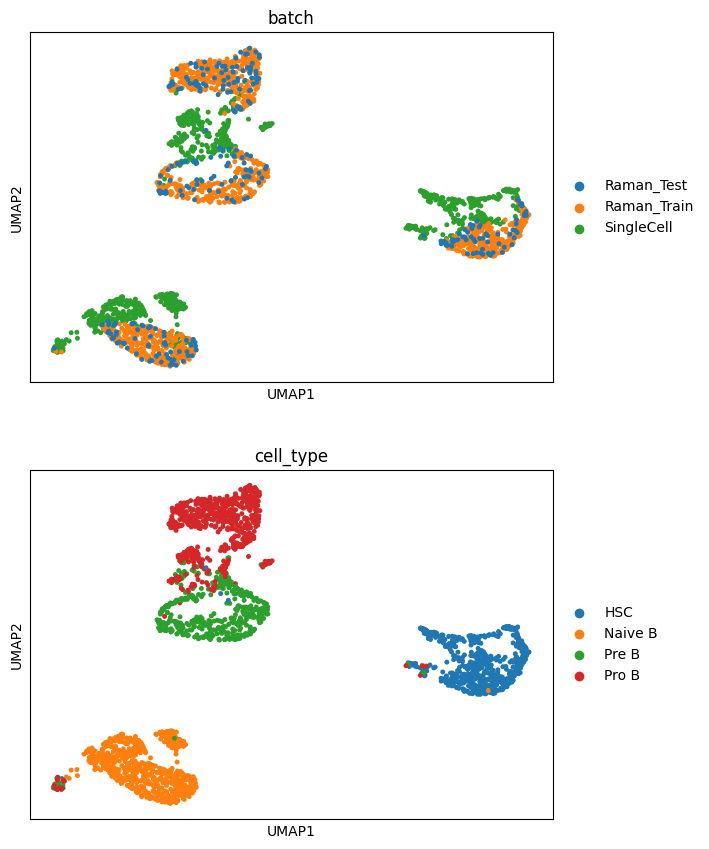

In [57]:
# ------------------------------------------------
# 7. 绘图
# ------------------------------------------------
sc.pl.umap(together_recon, color=['batch', 'cell_type'],ncols=1,save="_Raman2SC.pdf")

In [55]:
together_recon.obs.head()

,celltype,UMI_number,gene_number,individual,tissue,population,cluster,redefined_cluster,cell_type,n_genes_by_counts,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,batch
HSC_spBM1_L1_bar1-0,HSC,159315.0,4912.0,spBM1,spBM,sp,HSPC_C3,MEP1,HSC,4933.0,...,0.0,0.0,0.0,33849.0,10.429694,21.230862,53.0,3.988984,0.033243,SingleCell
HSC_spBM1_L1_bar2-0,HSC,63891.0,3991.0,spBM1,spBM,sp,HSPC_C11,EBM,HSC,4001.0,...,0.0,0.0,0.0,13020.0,9.474319,20.366663,0.0,0.000000,0.000000,SingleCell
HSC_spBM1_L1_bar3-0,HSC,64541.0,4223.0,spBM1,spBM,sp,HSPC_C2,HSC/MPP2,HSC,4232.0,...,0.0,0.0,0.0,20529.0,9.929643,31.798326,0.0,0.000000,0.000000,SingleCell
HSC_spBM1_L1_bar5-0,HSC,32009.0,4364.0,spBM1,spBM,sp,HSPC_C9,G2M,HSC,4374.0,...,0.0,0.0,0.0,8366.0,9.032051,26.123343,0.0,0.000000,0.000000,SingleCell
HSC_spBM1_L1_bar6-0,HSC,39670.0,4657.0,spBM1,spBM,sp,HSPC_C9,G2M,HSC,4662.0,...,0.0,0.0,0.0,8099.0,8.999619,20.411816,32.0,3.496508,0.080649,SingleCell


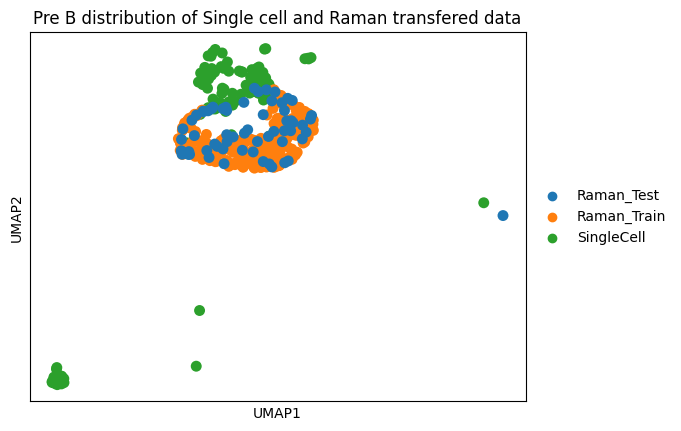

In [59]:
sc.pl.umap(together_recon[together_recon.obs["cell_type"] == "Pre B"],color=["batch"],title="Pre B distribution of Single cell and Raman transfered data",save="_Raman2SC_PreB.pdf")

In [60]:
together_recon.write("./data/Raman2SC_four_normal_celltype_abc.h5ad")

In [30]:
def test_vae(model, test_loader, device):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon_x, mean, logvar, latent = model(data)
            test_loss += F.mse_loss(recon_x, data, reduction='mean').item()

    test_loss /= len(test_loader.dataset)
    print(f'====> Test set loss: {test_loss:.4f}')
    return test_loss

# import umap
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt

# def visualize_latent_space(model, train_loader, test_loader, device):
#     model.eval()
#     train_latent_vectors = []
#     train_labels = []
#     test_latent_vectors = []
#     test_labels = []
    
#     with torch.no_grad():
#         for data, label in train_loader:
#             data = data.to(device)
#             _, _, _, latent = model(data)
#             train_latent_vectors.append(latent.cpu().numpy())
#             train_labels.append(label.cpu().numpy())
        
#         for data, label in test_loader:
#             data = data.to(device)
#             _, _, _, latent = model(data)
#             test_latent_vectors.append(latent.cpu().numpy())
#             test_labels.append(label.cpu().numpy())

#     train_latent_vectors = np.concatenate(train_latent_vectors, axis=0)
#     train_labels = np.concatenate(train_labels, axis=0)
#     test_latent_vectors = np.concatenate(test_latent_vectors, axis=0)
#     test_labels = np.concatenate(test_labels, axis=0)

#     # UMAP
#     umap_model = umap.UMAP(n_components=2, random_state=42)
#     train_latent_2d_umap = umap_model.fit_transform(train_latent_vectors)
#     test_latent_2d_umap = umap_model.transform(test_latent_vectors)

#     plt.figure(figsize=(10, 8))
#     plt.scatter(train_latent_2d_umap[:, 0], train_latent_2d_umap[:, 1], c=train_labels, cmap='viridis', marker='o', label='Train')
#     plt.scatter(test_latent_2d_umap[:, 0], test_latent_2d_umap[:, 1], c=test_labels, cmap='viridis', marker='x', label='Test')
#     plt.colorbar()
#     plt.title('Latent Space Visualization with UMAP')
#     plt.xlabel('UMAP Component 1')
#     plt.ylabel('UMAP Component 2')
#     plt.legend()
#     plt.show()

#     # t-SNE
#     # 1. 将训练集和测试集的向量拼到一起
#     all_latent_vectors = np.concatenate([train_latent_vectors, test_latent_vectors], axis=0)

#     # 2. 一次 fit_transform 学到公共的 t-SNE 空间
#     tsne_model = TSNE(n_components=2, random_state=42)
#     all_latent_2d_tsne = tsne_model.fit_transform(all_latent_vectors)

#     # 3. 将结果拆开
#     train_size = train_latent_vectors.shape[0]
#     train_latent_2d_tsne = all_latent_2d_tsne[:train_size]
#     test_latent_2d_tsne  = all_latent_2d_tsne[train_size:]


#     plt.figure(figsize=(10, 8))
#     plt.scatter(train_latent_2d_tsne[:, 0], train_latent_2d_tsne[:, 1], c=train_labels, cmap='viridis', marker='o', label='Train')
#     plt.scatter(test_latent_2d_tsne[:, 0], test_latent_2d_tsne[:, 1], c=test_labels, cmap='viridis', marker='x', label='Test')
#     plt.colorbar()
#     plt.title('Latent Space Visualization with t-SNE')
#     plt.xlabel('t-SNE Component 1')
#     plt.ylabel('t-SNE Component 2')
#     plt.legend()
#     plt.show()
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import numpy as np
import torch

def visualize_latent_space_discrete(model, train_loader, test_loader, device, class_names=None):
    model.eval()
    train_latent_vectors = []
    train_labels = []
    test_latent_vectors = []
    test_labels = []
    
    # 获取潜在空间表示和标签
    with torch.no_grad():
        for data, label in train_loader:
            data = data.to(device)
            _, _, _, latent = model(data)
            train_latent_vectors.append(latent.cpu().numpy())
            train_labels.append(label.cpu().numpy())
        
        for data, label in test_loader:
            data = data.to(device)
            _, _, _, latent = model(data)
            test_latent_vectors.append(latent.cpu().numpy())
            test_labels.append(label.cpu().numpy())

    train_latent_vectors = np.concatenate(train_latent_vectors, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)
    test_latent_vectors = np.concatenate(test_latent_vectors, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    # UMAP 降维
    umap_model = umap.UMAP(n_components=2, random_state=42)
    train_latent_2d_umap = umap_model.fit_transform(train_latent_vectors)
    test_latent_2d_umap = umap_model.transform(test_latent_vectors)

    # 设置离散调色板
    num_classes = len(np.unique(train_labels))
    palette = sns.color_palette("tab10", num_classes)
    colors = np.array(palette)

    plt.figure(figsize=(10, 8))

    # 绘制 Train
    for class_idx in range(num_classes):
        idx = train_labels == class_idx
        plt.scatter(train_latent_2d_umap[idx, 0], train_latent_2d_umap[idx, 1], 
                    color=colors[class_idx], label=f'Train {class_names[class_idx] if class_names else class_idx}', marker='o', alpha=0.7)

    # 绘制 Test
    for class_idx in range(num_classes):
        idx = test_labels == class_idx
        plt.scatter(test_latent_2d_umap[idx, 0], test_latent_2d_umap[idx, 1], 
                    edgecolor=colors[class_idx], facecolor='none', 
                    label=f'Test {class_names[class_idx] if class_names else class_idx}', 
                    marker='o', alpha=0.9, s=50, linewidth=1.5)


    plt.title('Latent Space Visualization with UMAP (Discrete Labels)')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [26]:
# 测试 VAE 模型
test_loss = test_vae(ref_vae, test_loader, device)

====> Test set loss: 0.0311


g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


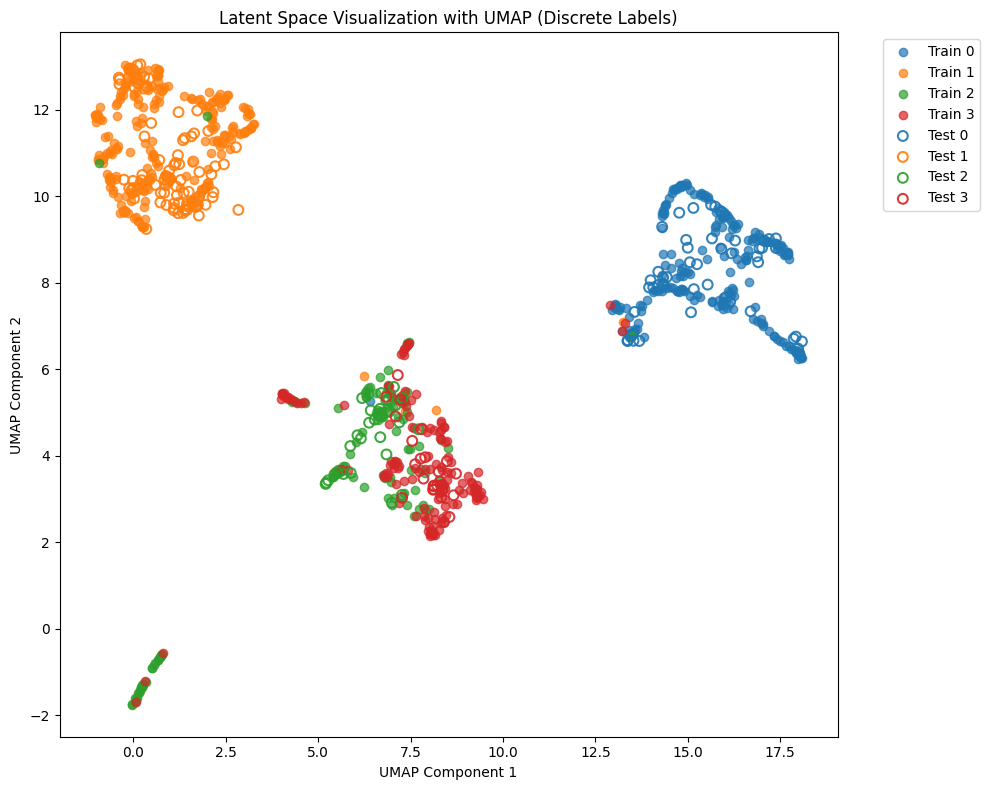

In [31]:
# 可视化隐藏层数据
visualize_latent_space_discrete(ref_vae, train_loader, test_loader, device)

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

class VAEOutput:
    def __init__(self, z_dist, z_sample, x_recon, loss, loss_recon, loss_kl):
        self.z_dist = z_dist
        self.z_sample = z_sample
        self.x_recon = x_recon
        self.loss = loss
        self.loss_recon = loss_recon
        self.loss_kl = loss_kl

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # 均值
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # 方差
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
    
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return Normal(self.fc21(h1), torch.exp(0.5 * self.fc22(h1)))
    
    def reparameterize(self, dist):
        return dist.rsample()
    
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)
    
    def forward(self, x, compute_loss=True):
        dist = self.encode(x)
        z = self.reparameterize(dist)
        recon_x = self.decode(z)

        if not compute_loss:
            return VAEOutput(
                z_dist=dist,
                z_sample=z,
                x_recon=recon_x,
                loss=None,
                loss_recon=None,
                loss_kl=None,
            )
        
        loss_recon = F.mse_loss(recon_x, x, reduction='sum')
        std_normal = Normal(torch.zeros_like(z, device=z.device), torch.ones_like(z, device=z.device))
        loss_kl = torch.distributions.kl.kl_divergence(dist, std_normal).sum()

        loss = loss_recon + loss_kl

        return VAEOutput(
            z_dist=dist,
            z_sample=z,
            x_recon=recon_x,
            loss=loss,
            loss_recon=loss_recon,
            loss_kl=loss_kl,
        )

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

class VAEOutput:
    def __init__(self, z_dist, z_sample, x_recon, loss, loss_recon, loss_kl):
        self.z_dist = z_dist
        self.z_sample = z_sample
        self.x_recon = x_recon
        self.loss = loss
        self.loss_recon = loss_recon
        self.loss_kl = loss_kl

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # 均值
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # 方差
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, input_dim)
    
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        return Normal(self.fc21(h2), torch.exp(0.5 * self.fc22(h2)))
    
    def reparameterize(self, dist):
        return dist.rsample()
    
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        h4 = F.relu(self.fc4(h3))
        return self.fc5(h4)
    
    def forward(self, x, compute_loss=True):
        dist = self.encode(x)
        z = self.reparameterize(dist)
        recon_x = self.decode(z)

        if torch.isnan(dist.loc).any() or torch.isnan(dist.scale).any():
            print("NaN detected in dist parameters")
            print("dist.loc:", dist.loc)
            print("dist.scale:", dist.scale)

        if not compute_loss:
            return VAEOutput(
                z_dist=dist,
                z_sample=z,
                x_recon=recon_x,
                loss=None,
                loss_recon=None,
                loss_kl=None,
            )
        
        loss_recon = F.mse_loss(recon_x, x, reduction='sum')
        std_normal = Normal(torch.zeros_like(z), torch.ones_like(z))
        loss_kl = torch.distributions.kl.kl_divergence(dist, std_normal).sum()

        loss = loss_recon + loss_kl

        return VAEOutput(
            z_dist=dist,
            z_sample=z,
            x_recon=recon_x,
            loss=loss,
            loss_recon=loss_recon,
            loss_kl=loss_kl,
        )

# 初始化模型参数
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import MultivariateNormal

class VAEOutput:
    def __init__(self, z_dist, z_sample, x_recon, loss, loss_recon, loss_kl):
        self.z_dist = z_dist
        self.z_sample = z_sample
        self.x_recon = x_recon
        self.loss = loss
        self.loss_recon = loss_recon
        self.loss_kl = loss_kl

class VAE(nn.Module):
    """
    Variational Autoencoder (VAE) class

    Args:
        input_dim(int): Dimensionality of the input data.
        hidden_dim(int): Dimensionality of the hidden layer.
        latent_dim(int): Dimensionality of the latent space.
    """

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),  # Swish activation function
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.SiLU(),
            nn.Linear(hidden_dim // 4, hidden_dim // 8),
            nn.SiLU(),
            nn.Linear(hidden_dim // 8, 2 * latent_dim),  # 2 for mean and variance.
        )
        self.softplus = nn.Softplus()

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 8),
            nn.SiLU(),
            nn.Linear(hidden_dim // 8, hidden_dim // 4),
            nn.SiLU(),
            nn.Linear(hidden_dim // 4, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x, eps: float = 1e-8):
        """
        Encodes the input data into the latent space
        
        Args:
            x (torch.Tensor): input data.
            eps (float): Small value to avoid numerical instability
        
        Returns:
            torch.distributions.MultivariateNormal: Normal distribution of the encoded data.
        """
        x = self.encoder(x)
        mu, logvar = torch.chunk(x, 2, dim=-1)
        scale = self.softplus(logvar) + eps
        scale_tril = torch.diag_embed(scale)

        return MultivariateNormal(mu, scale_tril=scale_tril)

    def reparameterize(self, dist):
        """
        Reparameterizes the encoded data to sample from the latent space

        Args:
            dist (torch.distributions.MultivariateNormal): Normal distributions of the encoded data.
        
        Returns:
            torch.Tensor: Sampled data from the latent space.
        """
        return dist.rsample()
    
    def decode(self, z):
        """
        Decodes the data from the latent space to the original input space.

        Args:
            z (torch.Tensor): Data in the latent space.
        
        Returns:
            torch.Tensor: Reconstructed data in the original input space.
        """
        return self.decoder(z)
    
    def forward(self, x, compute_loss: bool = True):
        """
        Performs a forward pass of the VAE.

        Args:
            x (torch.Tensor): Input data.
            compute_loss (bool): Whether to compute the loss or not.
        
        Returns:
            VAEOutput: VAE output dataclass.
        """
        dist = self.encode(x)
        z = self.reparameterize(dist)
        recon_x = self.decode(z)

        if not compute_loss:
            return VAEOutput(
                z_dist=dist,
                z_sample=z,
                x_recon=recon_x,
                loss=None,
                loss_recon=None,
                loss_kl=None,
            )
        
        loss_recon = F.mse_loss(recon_x, x, reduction='mean')
        std_normal = MultivariateNormal(
            torch.zeros_like(z, device=z.device),
            scale_tril=torch.eye(z.shape[-1], device=z.device).unsqueeze(0).expand(z.shape[0], -1, -1),
        )
        loss_kl = torch.distributions.kl.kl_divergence(dist, std_normal).mean()

        loss = loss_recon + loss_kl

        return VAEOutput(
            z_dist=dist,
            z_sample=z,
            x_recon=recon_x,
            loss=loss,
            loss_recon=loss_recon,
            loss_kl=loss_kl,
        )

In [33]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils as utils

device = torch.device("cpu")

input_dim = train_data.shape[1]
hidden_dim = 512
latent_dim = 2

model = VAE(input_dim, hidden_dim, latent_dim).to(device)
model.apply(weights_init)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)

epochs = 30  # 增加训练轮数
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = output.loss
        loss.backward()
        
        # 梯度裁剪
        utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 10 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    print(f'====> Epoch: {epoch} Average loss: {avg_train_loss:.4f}')
    
    # 调整学习率
    scheduler.step(avg_train_loss)

g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Train Epoch: 1 [0/750 (0%)]	Loss: 0.089953
Train Epoch: 1 [320/750 (42%)]	Loss: 0.065301
Train Epoch: 1 [640/750 (83%)]	Loss: 0.055844
====> Epoch: 1 Average loss: 0.0674
Train Epoch: 2 [0/750 (0%)]	Loss: 0.051505
Train Epoch: 2 [320/750 (42%)]	Loss: 0.042261
Train Epoch: 2 [640/750 (83%)]	Loss: 0.046374
====> Epoch: 2 Average loss: 0.0448
Train Epoch: 3 [0/750 (0%)]	Loss: 0.040474
Train Epoch: 3 [320/750 (42%)]	Loss: 0.036139
Train Epoch: 3 [640/750 (83%)]	Loss: 0.033974
====> Epoch: 3 Average loss: 0.0382
Train Epoch: 4 [0/750 (0%)]	Loss: 0.052912
Train Epoch: 4 [320/750 (42%)]	Loss: 0.036596
Train Epoch: 4 [640/750 (83%)]	Loss: 0.032541
====> Epoch: 4 Average loss: 0.0360
Train Epoch: 5 [0/750 (0%)]	Loss: 0.029416
Train Epoch: 5 [320/750 (42%)]	Loss: 0.036314
Train Epoch: 5 [640/750 (83%)]	Loss: 0.035521
====> Epoch: 5 Average loss: 0.0351
Train Epoch: 6 [0/750 (0%)]	Loss: 0.026658
Train Epoch: 6 [320/750 (42%)]	Loss: 0.026140
Train Epoch: 6 [640/750 (83%)]	Loss: 0.041953
====> Epoc

In [29]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon_x = self.decoder(z)
        return recon_x

In [30]:
import anndata
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 假设 abc_ad 是一个 AnnData 对象
# 选择高变基因
highly_variable_genes = abc_ad.var_names[abc_ad.var['highly_variable']]

# 获取高变基因的数据
data = abc_ad[:, highly_variable_genes].X
labels = abc_ad.obs['cell_type']

# 标准化数据
scaler = StandardScaler()
data = scaler.fit_transform(data)

# 将细胞类型标签转换为数值编码
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# 将数据分成训练集和测试集
train_data, test_data, train_labels, test_labels = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

# 将数据转换为 PyTorch 张量
train_tensor = torch.tensor(train_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

# 创建 TensorDataset
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
import torch.optim as optim

device = torch.device("cpu")

input_dim = train_data.shape[1]
hidden_dim = 400
latent_dim = 20

model = Autoencoder(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 30
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_data = model(data)
        loss = criterion(recon_data, data)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 10 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    print(f'====> Epoch: {epoch} Average loss: {avg_train_loss:.4f}')

Train Epoch: 1 [0/750 (0%)]	Loss: 0.028232
Train Epoch: 1 [320/750 (42%)]	Loss: 0.032437
Train Epoch: 1 [640/750 (83%)]	Loss: 0.032276
====> Epoch: 1 Average loss: 0.0319
Train Epoch: 2 [0/750 (0%)]	Loss: 0.027870
Train Epoch: 2 [320/750 (42%)]	Loss: 0.026711
Train Epoch: 2 [640/750 (83%)]	Loss: 0.029580
====> Epoch: 2 Average loss: 0.0315
Train Epoch: 3 [0/750 (0%)]	Loss: 0.033074
Train Epoch: 3 [320/750 (42%)]	Loss: 0.027042
Train Epoch: 3 [640/750 (83%)]	Loss: 0.039434
====> Epoch: 3 Average loss: 0.0306
Train Epoch: 4 [0/750 (0%)]	Loss: 0.026484
Train Epoch: 4 [320/750 (42%)]	Loss: 0.026009
Train Epoch: 4 [640/750 (83%)]	Loss: 0.024432
====> Epoch: 4 Average loss: 0.0301
Train Epoch: 5 [0/750 (0%)]	Loss: 0.030589
Train Epoch: 5 [320/750 (42%)]	Loss: 0.025097
Train Epoch: 5 [640/750 (83%)]	Loss: 0.023764
====> Epoch: 5 Average loss: 0.0298
Train Epoch: 6 [0/750 (0%)]	Loss: 0.034917
Train Epoch: 6 [320/750 (42%)]	Loss: 0.024779
Train Epoch: 6 [640/750 (83%)]	Loss: 0.027349
====> Epoc